In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import IsolationForest

# Detecção de Fraude em Transações de Varejo

## Objetivo

Desenvolver um pipeline completo de Machine Learning para detectar transações fraudulentas em operações de varejo e e-commerce.


In [35]:
df = pd.read_csv("../retail_fraud_detection_100k.csv")
df.head()

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,...,4,1054,0,0,0,1,0,1,0,Medium
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,...,2,97,0,0,0,0,0,0,0,Low
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,...,4,779,1,0,0,0,0,0,0,Medium
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,...,3,286,1,1,0,1,0,1,1,High
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,...,3,866,0,0,0,1,0,0,0,Low


In [36]:
print("Shape:", df.shape)
df.info()

Shape: (100000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   transaction_id                    100000 non-null  object 
 1   customer_id                       100000 non-null  object 
 2   transaction_timestamp             100000 non-null  object 
 3   transaction_amount                100000 non-null  float64
 4   payment_method                    100000 non-null  object 
 5   device_type                       100000 non-null  object 
 6   location                          100000 non-null  object 
 7   merchant_category                 100000 non-null  object 
 8   is_international                  100000 non-null  int64  
 9   transaction_frequency_24h         100000 non-null  int64  
 10  avg_transaction_amount_7d         100000 non-null  float64
 11  failed_transaction_count_24h     

In [9]:
df.describe(include='all')

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
count,100000,100000,100000,100000.000000,100000,100000,100000,100000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000
unique,100000,28955,100000,NaN,5,3,6,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,T0099984,C00353,2025-08-31 19:56:25.768710,NaN,Apple Pay,Mobile,Germany,Fashion,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium
freq,1,13,1,NaN,20098,33454,16759,16893,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52211
mean,NaN,NaN,NaN,120.475407,NaN,NaN,NaN,NaN,0.498010,7.489910,...,2.003560,1005.329380,0.500150,0.229530,0.498010,0.427040,0.100960,0.283980,0.475080,NaN
std,NaN,NaN,NaN,119.787252,NaN,NaN,NaN,NaN,0.499999,4.024028,...,1.414923,573.313726,0.500002,0.420533,0.499999,0.494651,0.301277,0.450929,0.499381,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,1.000000,...,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,34.820000,NaN,NaN,NaN,NaN,0.000000,4.000000,...,1.000000,510.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,NaN,NaN,NaN,84.130000,NaN,NaN,NaN,NaN,0.000000,7.000000,...,2.000000,1004.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,NaN,NaN,NaN,167.520000,NaN,NaN,NaN,NaN,1.000000,11.000000,...,3.000000,1501.250000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,NaN


In [10]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
transaction_timestamp,0
transaction_amount,0
payment_method,0
device_type,0
location,0
merchant_category,0
is_international,0
transaction_frequency_24h,0


## Análise Exploratória

Nesta etapa foram analisadas as distribuições das variáveis, correlações e o balanceamento das classes.


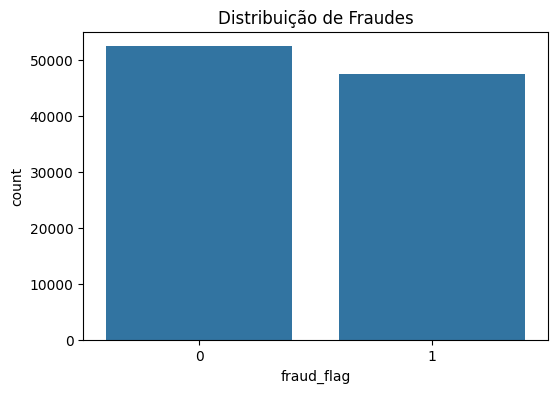

fraud_flag
0    52.492
1    47.508
Name: proportion, dtype: float64


In [56]:
plt.figure(figsize=(6,4))
sns.countplot(x='fraud_flag', data=df)
plt.title("Distribuição de Fraudes")
plt.show()

print(df['fraud_flag'].value_counts(normalize=True)*100)

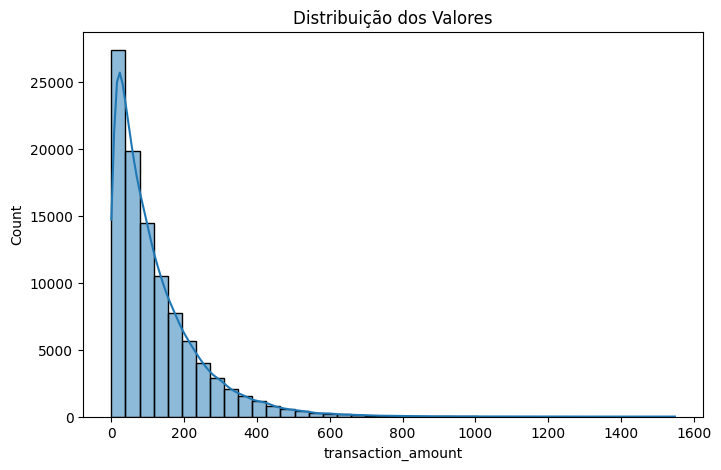

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(df['transaction_amount'], bins=40, kde=True)
plt.title("Distribuição dos Valores")
plt.show()

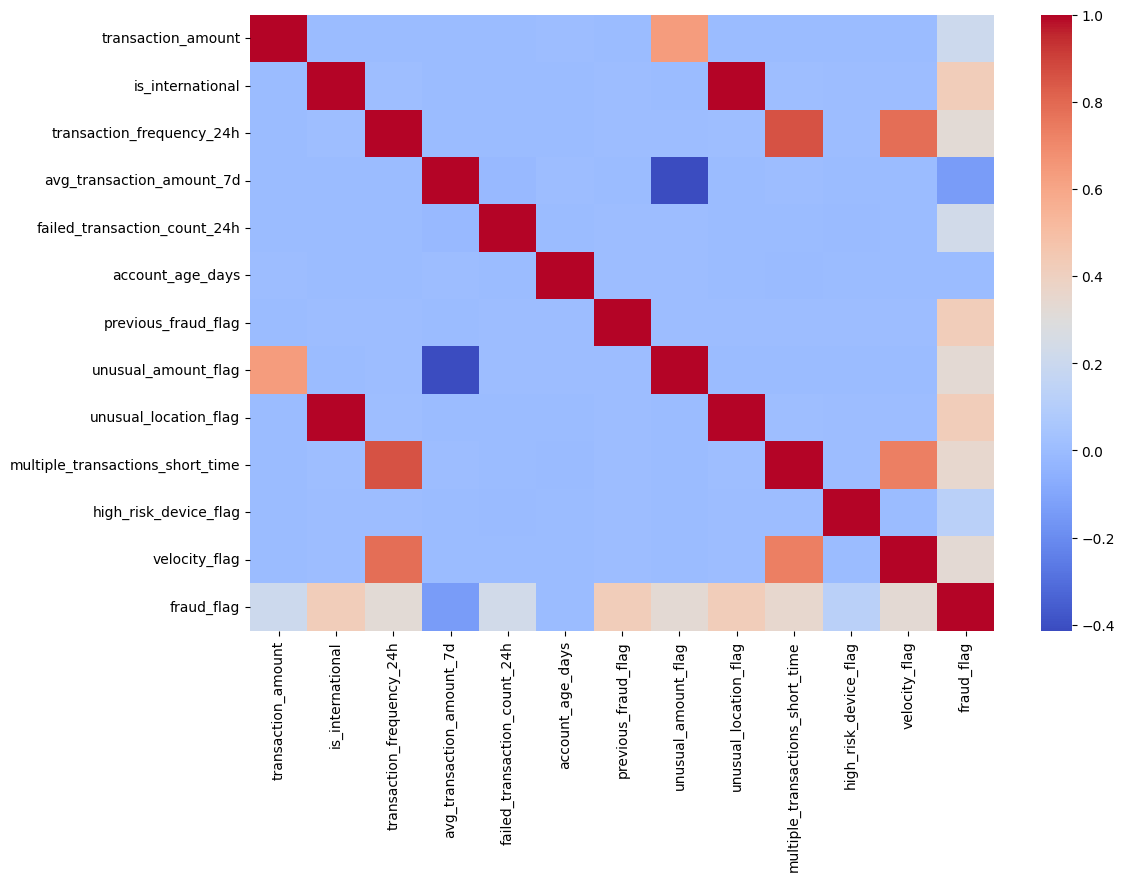

In [54]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    cmap='coolwarm'
)
plt.show()

Foi observada forte correlação entre fraude e variáveis comportamentais como velocity_flag, unusual_location_flag e high_risk_device_flag.


In [38]:
columns_to_drop = [
    'transaction_id',
    'customer_id',
    'transaction_timestamp'
]

# Verifica se as colunas existem antes de tentar removê-las
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df = df.drop(existing_columns_to_drop, axis=1)
    print(f"Colunas {existing_columns_to_drop} removidas com sucesso.")
else:
    print("As colunas especificadas já foram removidas ou não existem no DataFrame.")

Colunas ['transaction_id', 'customer_id', 'transaction_timestamp'] removidas com sucesso.


In [17]:
X = df.drop("fraud_flag", axis=1)
y = df["fraud_flag"]

In [18]:
X = pd.get_dummies(X, drop_first=True)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modelagem

Foram treinados três modelos supervisionados e um método de detecção de anomalias.


In [ ]:
## Modelagem

Foram treinados três modelos supervisionados e um método de detecção de anomalias.


In [49]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [50]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
# Probabilidades para cálculo do ROC-AUC

prob_lr = lr.predict_proba(X_test)[:, 1]

prob_rf = rf.predict_proba(X_test)[:, 1]

prob_gb = gb.predict_proba(X_test)[:, 1]

In [51]:
def avaliar(nome, y_true, pred, prob=None):

    print("="*40)
    print("Modelo:", nome)
    print("Accuracy:", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred))
    print("Recall:", recall_score(y_true, pred))
    print("F1:", f1_score(y_true, pred))

    if prob is not None:
        print("ROC-AUC:", roc_auc_score(y_true, prob))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, pred))

In [52]:
avaliar("Logistic Regression", y_test, pred_lr, prob_lr)

avaliar("Random Forest", y_test, pred_rf, prob_rf)

avaliar("Gradient Boosting", y_test, pred_gb, prob_gb)

Modelo: Logistic Regression
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0

Confusion Matrix:
[[10363     0]
 [    0  9637]]
Modelo: Random Forest
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0

Confusion Matrix:
[[10363     0]
 [    0  9637]]
Modelo: Gradient Boosting
Accuracy: 0.9986
Precision: 0.9981337480559875
Recall: 0.998962332676144
F1: 0.9985478684783736
ROC-AUC: 0.9999799936378166

Confusion Matrix:
[[10345    18]
 [   10  9627]]


In [29]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso.fit(X_train)
pred_iso = iso.predict(X_test)
pred_iso = np.where(pred_iso == -1, 1, 0)

avaliar("Isolation Forest", y_test, pred_iso)

Modelo: Isolation Forest
Accuracy: 0.5443
Precision: 0.7556207233626588
Recall: 0.08021168413406662
F1: 0.1450281425891182

Confusion Matrix:
[[10113   250]
 [ 8864   773]]


In [53]:
lr = LogisticRegression(random_state=42, solver='liblinear') # Adicionando solver para evitar warning
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

resultados = pd.DataFrame({

    "Modelo":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "Isolation Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_gb),
        accuracy_score(y_test,pred_iso)
    ],

    "F1":[
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_rf),
        f1_score(y_test,pred_gb),
        f1_score(y_test,pred_iso)
    ],

    "ROC-AUC":[
        roc_auc_score(y_test,prob_lr),
        roc_auc_score(y_test,prob_rf),
        roc_auc_score(y_test,prob_gb),
        np.nan
    ]

})

resultados

,Modelo,Accuracy,F1,ROC-AUC
0,Logistic Regression,1.0000,1.000000,1.00000
1,Random Forest,1.0000,1.000000,1.00000
2,Gradient Boosting,0.9986,0.998548,0.99998
3,Isolation Forest,0.5443,0.145028,NaN


## Conclusão

Os resultados demonstraram que a Logistic Regression e o Random Forest apresentaram desempenho praticamente perfeito nas métricas avaliadas (Accuracy, Precision, Recall, F1-score e ROC-AUC). O Gradient Boosting também apresentou excelente desempenho, embora ligeiramente inferior. Em contrapartida, o Isolation Forest obteve resultados significativamente menores, evidenciando que, para este conjunto de dados, os modelos supervisionados são mais eficazes na detecção de fraudes.
